# Quiz Data — Exploratory Data Analysis

**Standalone notebook** — logic mirrors `src/eda.py` (same outputs under `outputs/eda/`).

Update paths below if needed. Run cells in order.


## 1  Imports & configuration


In [1]:
from pathlib import Path
import os
# Repo root whether kernel cwd is repo or notebooks/
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

QUIZ1_PATH = REPO_ROOT / "data/quiz1/quiz1_marks.csv"
QUIZ2_PATH = REPO_ROOT / "data/quiz2/quiz2_marks.csv"
QUIZ3_PATH = REPO_ROOT / "data/quiz3/quiz3_marks.csv"

OUT_DIR = REPO_ROOT / "outputs" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = ["#2E86AB", "#E84855", "#F4A261"]
SUCCESS = "#22C55E"
NEUTRAL = "#6B7280"

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
print("Setup complete — OUT_DIR =", OUT_DIR)


Setup complete — OUT_DIR = D:\abi\admin\Data-Viz\outputs\eda


## 2  Helper functions (same as `src/data_io.py` + EDA helpers)


In [2]:
def parse_time_to_seconds(text) -> float:
    if pd.isna(text):
        return np.nan
    s = str(text).strip()
    if s in ("-", ""):
        return np.nan
    sl = s.lower()
    total = 0.0
    for pattern, mul in [
        (r"(\d+)\s*days?", 86400),
        (r"(\d+)\s*hours?", 3600),
        (r"(\d+)\s*mins?", 60),
        (r"(\d+)\s*secs?", 1),
    ]:
        m = re.search(pattern, sl)
        if m:
            total += int(m.group(1)) * mul
    return total if total > 0 else np.nan


def time_sec_to_minutes(time_sec: pd.Series) -> pd.Series:
    s = time_sec.astype(float)
    as_sec = s / 60.0
    as_ms = s / 60_000.0
    use_ms = (as_sec > 720.0) & (as_ms <= 720.0) & (as_sec < 10_000.0)
    return pd.Series(np.where(use_ms, as_ms, as_sec), index=time_sec.index, dtype=float)


def load_quiz(path: Path, quiz_id: int) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[df["State"] == "Finished"].copy()
    df["grade"] = pd.to_numeric(df["Grade/10.00"], errors="coerce")
    df["time_sec"] = df["Time taken"].apply(parse_time_to_seconds)
    df["time_min"] = time_sec_to_minutes(df["time_sec"])
    q_cols = [c for c in df.columns if c.startswith("Q.")]
    for c in q_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.rename(columns={"Student Code": "student_id"})
    df["quiz"] = quiz_id
    started = df["Started on"].astype(str).str.replace(r"\s+", " ", regex=True)
    df["started_on"] = pd.to_datetime(started, errors="coerce", dayfirst=True, format="mixed")
    df = df.sort_values(["student_id", "started_on"])
    df["attempt_no"] = df.groupby("student_id").cumcount() + 1
    keep = ["student_id", "quiz", "attempt_no", "grade", "time_sec", "time_min", "started_on"] + q_cols
    return df[keep].dropna(subset=["grade", "time_sec"]).reset_index(drop=True)


def triplets(q1, q2, q3):
    return [(q1, "Quiz 1"), (q2, "Quiz 2"), (q3, "Quiz 3")]


def get_q_cols(df):
    return [c for c in df.columns if c.startswith("Q.")]

print("Helpers OK")


Helpers OK


## 3  Load data


In [3]:
q1 = load_quiz(QUIZ1_PATH, 1)
q2 = load_quiz(QUIZ2_PATH, 2)
q3 = load_quiz(QUIZ3_PATH, 3)
print(f"Quiz 1: {len(q1):,} attempts ({q1['student_id'].nunique()} students)")
print(f"Quiz 2: {len(q2):,} attempts ({q2['student_id'].nunique()} students)")
print(f"Quiz 3: {len(q3):,} attempts ({q3['student_id'].nunique()} students)")
q1.head(3)


Quiz 1: 13,911 attempts (6656 students)
Quiz 2: 10,430 attempts (6656 students)
Quiz 3: 8,066 attempts (6635 students)


,student_id,quiz,attempt_no,grade,time_sec,time_min,started_on,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00
0,1,1,1,6.0,445.0,7.416667,2022-03-14 06:55:00,0.0,2.0,2.0,2.0,0.0
1,1,1,2,10.0,64.0,1.066667,2022-03-14 07:11:00,2.0,2.0,2.0,2.0,2.0
2,2,1,1,4.0,1173.0,19.550000,2022-03-14 17:42:00,0.0,2.0,2.0,0.0,0.0


## 4  Data quality → `eda_data_quality.csv`


In [4]:
rows_dq = []
for path, qid in [(QUIZ1_PATH, 1), (QUIZ2_PATH, 2), (QUIZ3_PATH, 3)]:
    raw = pd.read_csv(path)
    fin = raw[raw["State"] == "Finished"]
    g = pd.to_numeric(fin["Grade/10.00"], errors="coerce")
    t = fin["Time taken"].apply(parse_time_to_seconds)
    rows_dq.append({
        "quiz": f"Quiz {qid}",
        "rows_total": len(raw),
        "finished": len(fin),
        "finished_missing_grade": int(g.isna().sum()),
        "finished_unparseable_time": int(t.isna().sum()),
        "rows_in_analysis_sample": int((g.notna() & t.notna()).sum()),
    })
dq = pd.DataFrame(rows_dq)
dq.to_csv(OUT_DIR / "eda_data_quality.csv", index=False)
display(dq)


,quiz,rows_total,finished,finished_missing_grade,finished_unparseable_time,rows_in_analysis_sample
0,Quiz 1,13989,13911,0,0,13911
1,Quiz 2,10474,10430,0,0,10430
2,Quiz 3,8133,8066,0,0,8066


## 5  Student overlap → `eda_cross_quiz_students.csv`


In [5]:
s1, s2, s3 = set(q1["student_id"]), set(q2["student_id"]), set(q3["student_id"])
overlap = pd.DataFrame([
    {"scope": "Quiz 1 only", "count": len(s1 - s2 - s3)},
    {"scope": "Quiz 2 only", "count": len(s2 - s1 - s3)},
    {"scope": "Quiz 3 only", "count": len(s3 - s1 - s2)},
    {"scope": "Q1 ∩ Q2", "count": len(s1 & s2)},
    {"scope": "Q1 ∩ Q3", "count": len(s1 & s3)},
    {"scope": "Q2 ∩ Q3", "count": len(s2 & s3)},
    {"scope": "All three quizzes", "count": len(s1 & s2 & s3)},
])
overlap.to_csv(OUT_DIR / "eda_cross_quiz_students.csv", index=False)
display(overlap)


,scope,count
0,Quiz 1 only,0
1,Quiz 2 only,0
2,Quiz 3 only,0
3,Q1 ∩ Q2,6656
4,Q1 ∩ Q3,6635
5,Q2 ∩ Q3,6635
6,All three quizzes,6635


## 6  Re-attempt behaviour → `eda_student_attempts.csv`


In [6]:
rows_sa = []
for df, name in triplets(q1, q2, q3):
    mx = df.groupby("student_id")["attempt_no"].max()
    n_stu = mx.size
    multi = int((mx >= 2).sum())
    rows_sa.append({
        "quiz": name,
        "students": n_stu,
        "pct_with_2plus_attempts": round(100 * multi / max(n_stu, 1), 2),
        "mean_attempts_per_student": round(df.groupby("student_id").size().mean(), 3),
        "max_attempts_observed": int(mx.max()),
    })
sa = pd.DataFrame(rows_sa)
sa.to_csv(OUT_DIR / "eda_student_attempts.csv", index=False)
display(sa)


,quiz,students,pct_with_2plus_attempts,mean_attempts_per_student,max_attempts_observed
0,Quiz 1,6656,65.97,2.090,7
1,Quiz 2,6656,38.78,1.567,6
2,Quiz 3,6635,17.45,1.216,5


### Figure: `eda_attempts_per_student.png`


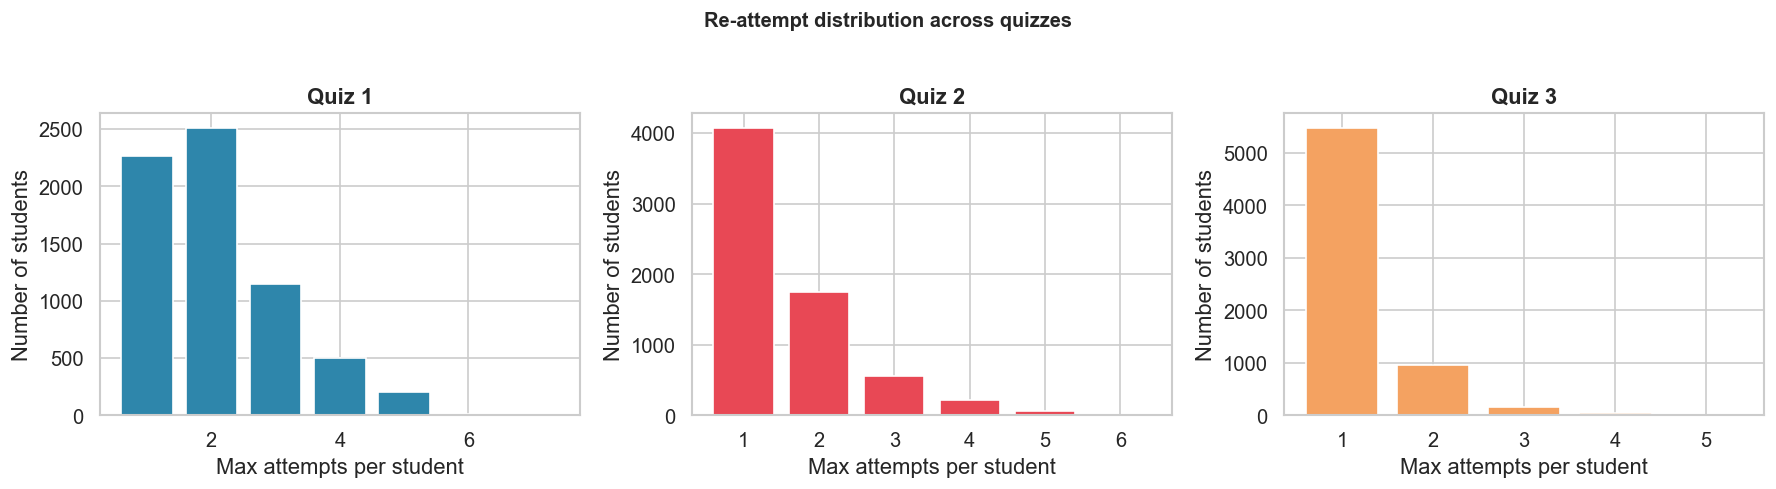

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, title), c in zip(axes, triplets(q1, q2, q3), COLORS):
    mx = df.groupby("student_id")["attempt_no"].max()
    vc = mx.value_counts().sort_index()
    ax.bar(vc.index.astype(int), vc.values, color=c, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Max attempts per student")
    ax.set_ylabel("Number of students")
plt.suptitle("Re-attempt distribution across quizzes", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_attempts_per_student.png", bbox_inches="tight")
plt.show()


## 7  Grade distributions


### Figure: `eda_grade_histograms.png`


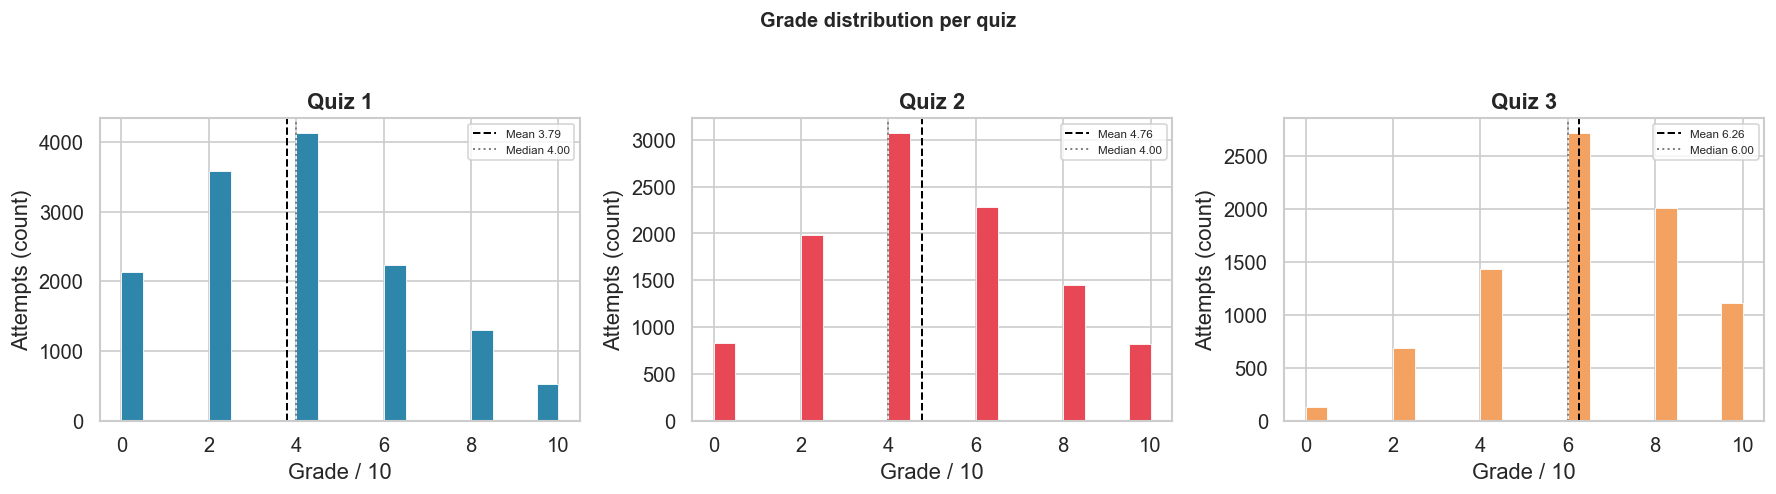

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, title), c in zip(axes, triplets(q1, q2, q3), COLORS):
    ax.hist(df["grade"].dropna(), bins=np.arange(0, 10.5, 0.5), color=c, edgecolor="white", linewidth=0.5)
    ax.axvline(df["grade"].mean(), color="black", linestyle="--", linewidth=1.2, label=f"Mean {df['grade'].mean():.2f}")
    ax.axvline(df["grade"].median(), color="grey", linestyle=":", linewidth=1.2, label=f"Median {df['grade'].median():.2f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Grade / 10")
    ax.set_ylabel("Attempts (count)")
    ax.legend(fontsize=7)
plt.suptitle("Grade distribution per quiz", fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_grade_histograms.png", bbox_inches="tight")
plt.show()


### Figure: `eda_grade_ecdf_by_quiz.png`


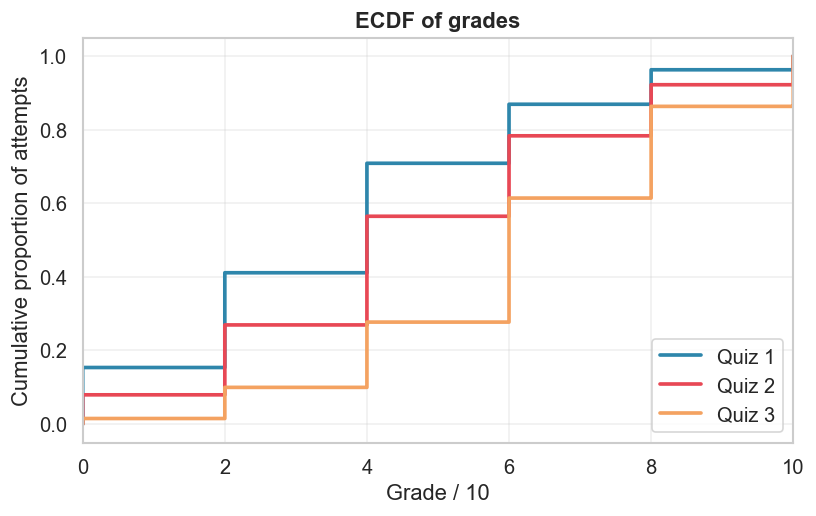

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for (df, title), c in zip(triplets(q1, q2, q3), COLORS):
    x = np.sort(df["grade"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, drawstyle="steps-post", color=c, lw=2.2, label=title)
ax.set_xlabel("Grade / 10")
ax.set_ylabel("Cumulative proportion of attempts")
ax.set_title("ECDF of grades", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_grade_ecdf_by_quiz.png", bbox_inches="tight")
plt.show()


### Table: `eda_numeric_summary.csv`


In [10]:
rows_ns = []
for df, name in triplets(q1, q2, q3):
    g, tm = df["grade"], df["time_min"]
    rows_ns.append({
        "dataset": name,
        "n_attempts": len(df),
        "n_students": df["student_id"].nunique(),
        "grade_mean": round(g.mean(), 3),
        "grade_std": round(g.std(), 3),
        "grade_median": round(g.median(), 3),
        "grade_p25": round(g.quantile(0.25), 3),
        "grade_p75": round(g.quantile(0.75), 3),
        "pct_ge_6": round(100 * (g >= 6).mean(), 2),
        "pct_ge_8": round(100 * (g >= 8).mean(), 2),
        "time_median_min": round(tm.median(), 3),
        "time_mean_min": round(tm.mean(), 3),
        "pct_over_60min": round(100 * (tm > 60).mean(), 2),
    })
summary = pd.DataFrame(rows_ns)
summary.to_csv(OUT_DIR / "eda_numeric_summary.csv", index=False)
display(summary)


,dataset,n_attempts,n_students,grade_mean,grade_std,grade_median,grade_p25,grade_p75,pct_ge_6,pct_ge_8,time_median_min,time_mean_min,pct_over_60min
0,Quiz 1,13911,6656,3.791,2.634,4.0,2.0,6.0,29.16,13.13,5.500,415.122,2.34
1,Quiz 2,10430,6656,4.763,2.713,4.0,2.0,6.0,43.55,21.70,6.250,573.770,3.52
2,Quiz 3,8066,6635,6.262,2.394,6.0,4.0,8.0,72.29,38.61,5.917,497.555,2.94


## 8  Time-on-task (matches `plot_time_histograms` + `plot_time_box_by_quiz`)


### Figure: `eda_time_histograms.png` (vertical boxplots)


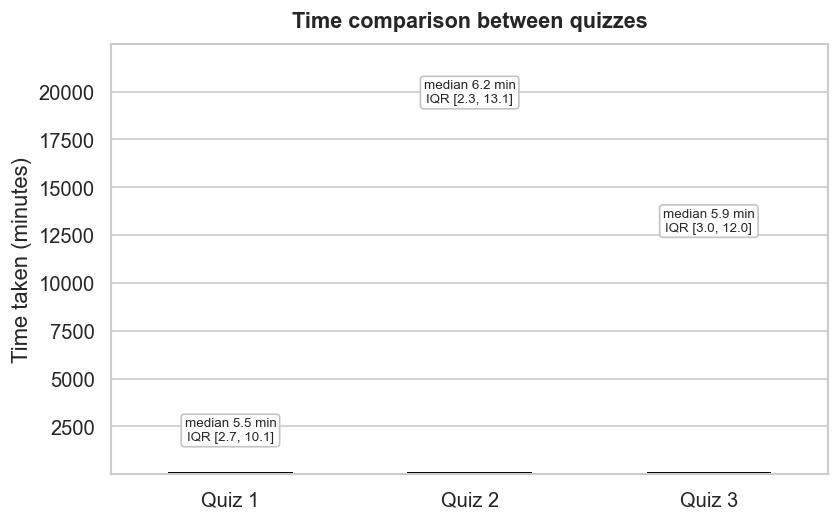

In [11]:
quiz_order = ["Quiz 1", "Quiz 2", "Quiz 3"]
parts = []
for df, name in triplets(q1, q2, q3):
    cap = df["time_min"].quantile(0.995)
    d = df.loc[df["time_min"] <= cap, ["time_min"]].copy()
    d["quiz"] = name
    parts.append(d)
long_t = pd.concat(parts, ignore_index=True)
pal = dict(zip(quiz_order, COLORS))

fig, ax = plt.subplots(figsize=(7.2, 5.2))
sns.boxplot(
    data=long_t, x="quiz", y="time_min", order=quiz_order, hue="quiz", palette=pal,
    width=0.52, ax=ax, legend=False, dodge=False, showfliers=False,
    medianprops=dict(color="black", linewidth=2.4),
    boxprops=dict(edgecolor="0.35", linewidth=1.0),
)
ax.set_xlabel("")
ax.set_ylabel("Time taken (minutes)")
ax.set_title("Time comparison between quizzes", fontsize=13, fontweight="bold", pad=10)
y_hi, y_lo = long_t["time_min"].max(), long_t["time_min"].min()
pad = 0.05 * (y_hi - y_lo + 1e-6)
for i, qz in enumerate(quiz_order):
    sub = long_t.loc[long_t["quiz"] == qz, "time_min"]
    ax.text(
        i, sub.max() + pad,
        f"median {sub.median():.1f} min\nIQR [{sub.quantile(.25):.1f}, {sub.quantile(.75):.1f}]",
        ha="center", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.75", alpha=0.92),
    )
ax.set_ylim(y_lo, y_hi + 4.5 * pad)
plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.savefig(OUT_DIR / "eda_time_histograms.png", bbox_inches="tight")
plt.show()


### Figure: `eda_time_boxplot_by_quiz.png` (horizontal)


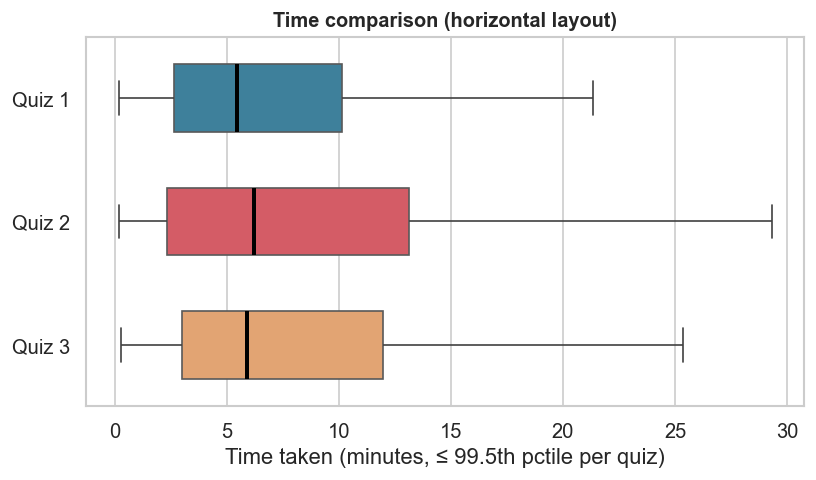

In [12]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
sns.boxplot(
    data=long_t, y="quiz", x="time_min", order=quiz_order, hue="quiz", palette=pal,
    width=0.55, ax=ax, legend=False, dodge=False, orient="h", showfliers=False,
    medianprops=dict(color="black", linewidth=2.4),
    boxprops=dict(edgecolor="0.35", linewidth=1.0),
)
ax.set_xlabel("Time taken (minutes, ≤ 99.5th pctile per quiz)")
ax.set_ylabel("")
ax.set_title("Time comparison (horizontal layout)", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_time_boxplot_by_quiz.png", bbox_inches="tight")
plt.show()


## 9  Grade vs time — hexbin → `eda_grade_vs_time_hexbin.png`


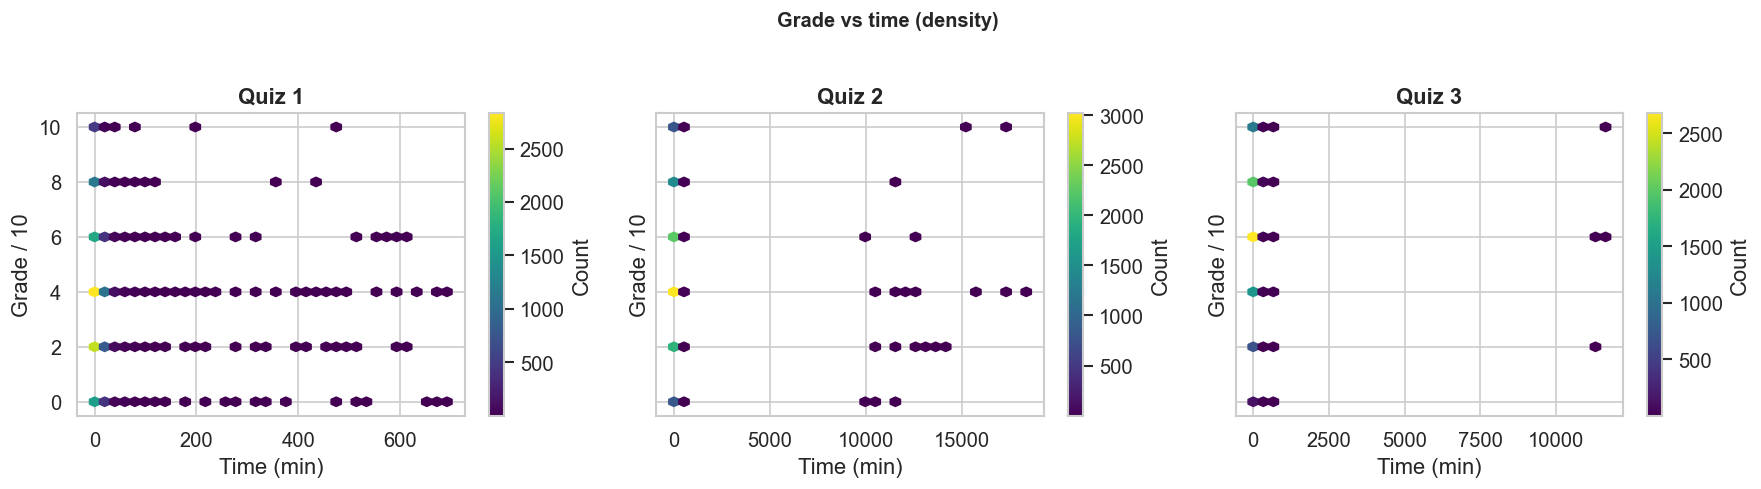

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (df, title), c in zip(axes, triplets(q1, q2, q3), COLORS):
    cap = df["time_min"].quantile(0.995)
    d = df[df["time_min"] <= cap]
    hb = ax.hexbin(d["time_min"], d["grade"], gridsize=35, cmap="viridis", mincnt=1)
    plt.colorbar(hb, ax=ax, label="Count")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Grade / 10")
plt.suptitle("Grade vs time (density)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_grade_vs_time_hexbin.png", bbox_inches="tight")
plt.show()


## 10  First → last grade → table + `eda_first_to_last_grade_delta.png`


,quiz,n_students_multi,mean_delta_last_minus_first,median_delta,pct_improved
0,Quiz 1,4391,4.2095,4.0,95.65
1,Quiz 2,2581,4.3681,4.0,96.82
2,Quiz 3,1158,4.1727,4.0,93.35


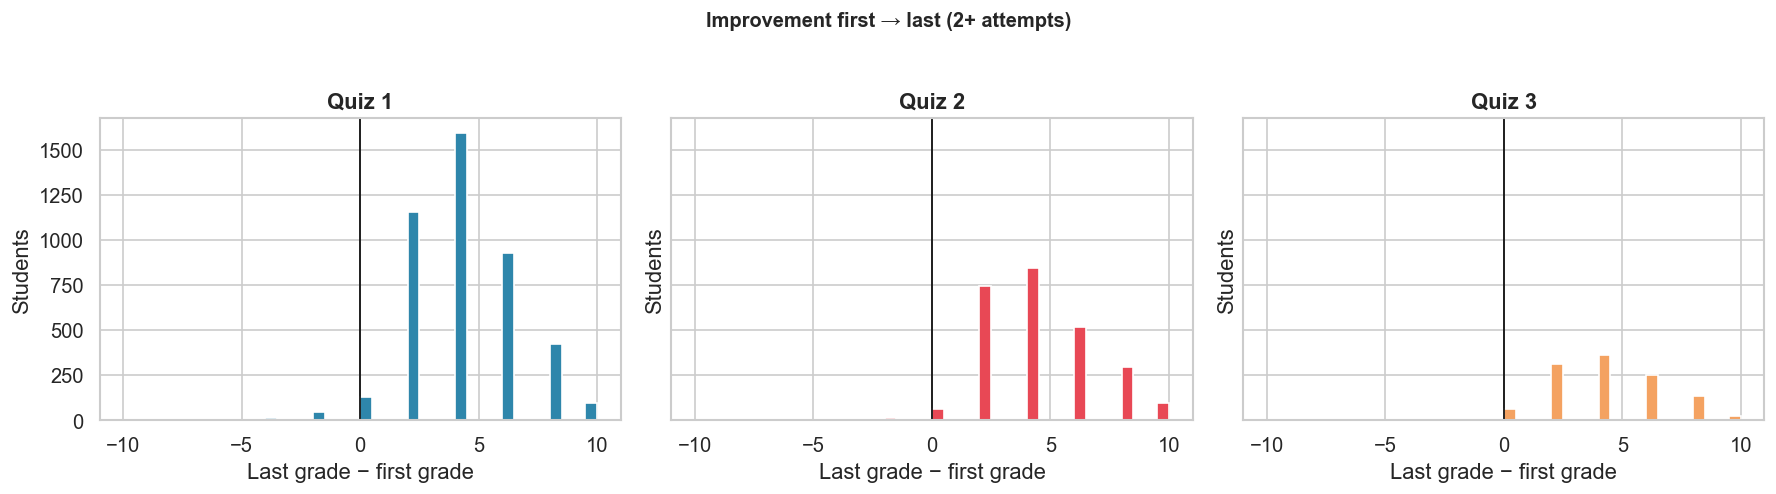

In [14]:
rows_fl = []
for df, name in triplets(q1, q2, q3):
    o = df.sort_values(["student_id", "attempt_no"])
    grp = o.groupby("student_id", group_keys=False)
    first = grp["grade"].first()
    last = grp["grade"].last()
    mask = grp["attempt_no"].max() >= 2
    d = (last - first)[mask].dropna()
    rows_fl.append({
        "quiz": name,
        "n_students_multi": int(mask.sum()),
        "mean_delta_last_minus_first": round(float(d.mean()), 4) if len(d) else np.nan,
        "median_delta": round(float(d.median()), 4) if len(d) else np.nan,
        "pct_improved": round(100 * float((d > 0).mean()), 2) if len(d) else np.nan,
    })
fl = pd.DataFrame(rows_fl)
fl.to_csv(OUT_DIR / "eda_first_to_last_delta.csv", index=False)
display(fl)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (df, title), c in zip(axes, triplets(q1, q2, q3), COLORS):
    o = df.sort_values(["student_id", "attempt_no"])
    grp = o.groupby("student_id", group_keys=False)
    mask = grp["attempt_no"].max() >= 2
    d = (grp["grade"].last() - grp["grade"].first())[mask].dropna()
    ax.hist(d, bins=np.arange(-10, 10.5, 0.5), color=c, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Last grade − first grade")
    ax.set_ylabel("Students")
plt.suptitle("Improvement first → last (2+ attempts)", fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_first_to_last_grade_delta.png", bbox_inches="tight")
plt.show()


## 11  Per-question difficulty


### Figure: `eda_question_mean_marks.png`


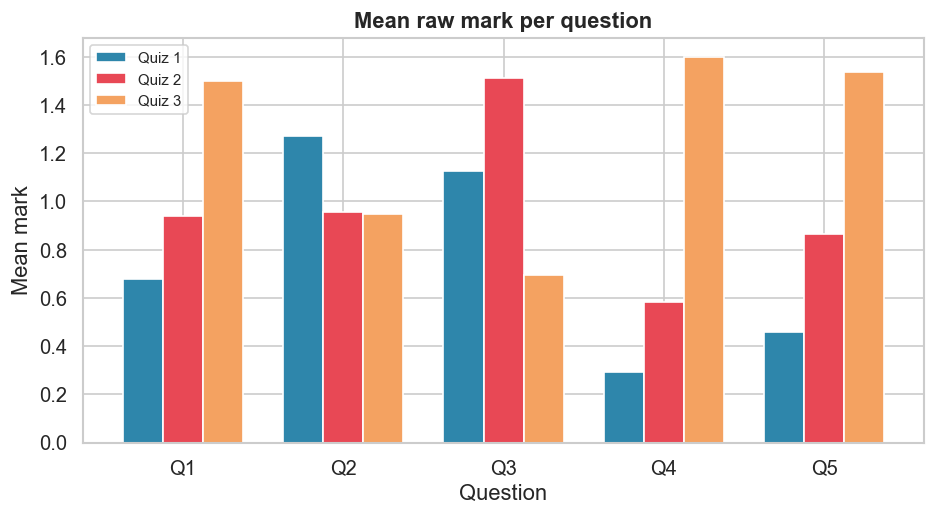

In [15]:
long_q = []
for df, qname in triplets(q1, q2, q3):
    for c in get_q_cols(df):
        qix = c.split()[1].rstrip(".")
        long_q.append({"question": f"Q{qix}", "quiz": qname, "mean_mark": df[c].mean()})
long_q = pd.DataFrame(long_q)
pivot = long_q.pivot(index="question", columns="quiz", values="mean_mark")

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(kind="bar", ax=ax, width=0.75, color=COLORS)
ax.set_title("Mean raw mark per question", fontweight="bold")
ax.set_xlabel("Question")
ax.set_ylabel("Mean mark")
ax.legend(fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_question_mean_marks.png", bbox_inches="tight")
plt.show()


### Figure: `eda_question_difficulty_heatmap.png`


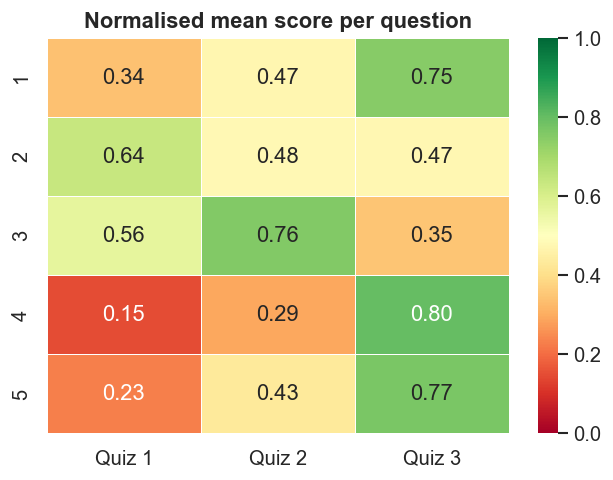

In [16]:
norm_cols = {}
for df, qname in triplets(q1, q2, q3):
    series = {}
    for c in get_q_cols(df):
        try:
            mx = float(c.split("/")[1])
        except (IndexError, ValueError):
            mx = float(df[c].max())
        qix = c.split()[1].rstrip(".")
        series[qix] = df[c].mean() / mx
    norm_cols[qname] = series

order = [c.split()[1].rstrip(".") for c in get_q_cols(q1)]
mat = pd.DataFrame({k: [norm_cols[k][qi] for qi in order] for k in ["Quiz 1", "Quiz 2", "Quiz 3"]}, index=order)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Normalised mean score per question", fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_question_difficulty_heatmap.png", bbox_inches="tight")
plt.show()


## 12  Attempt timeline → `eda_attempts_timeline.png`


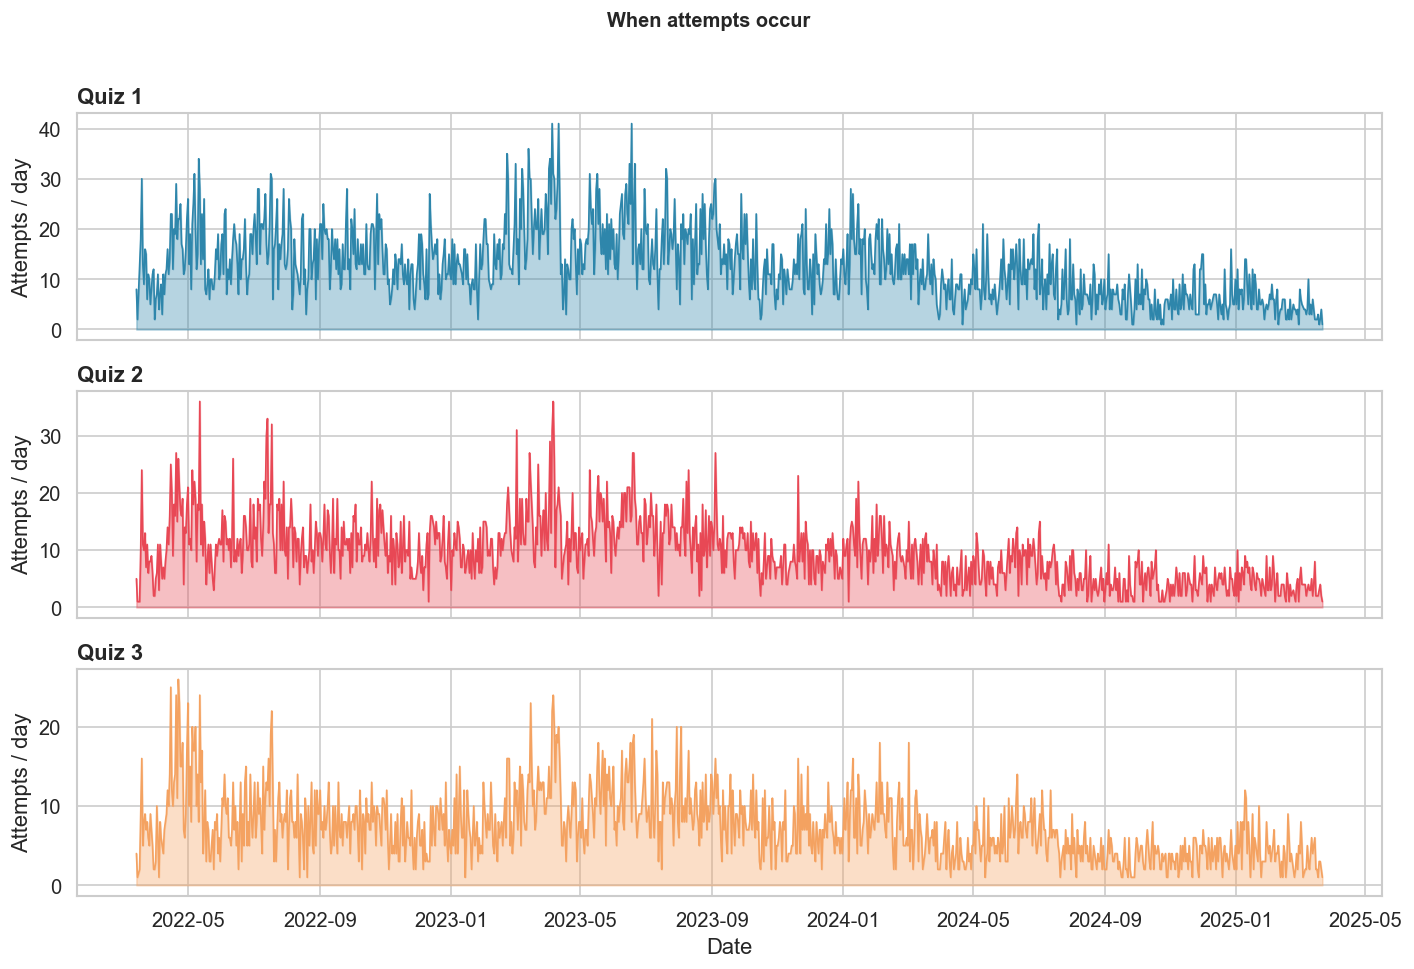

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, df, title, c in zip(axes, [q1, q2, q3], ["Quiz 1", "Quiz 2", "Quiz 3"], COLORS):
    d = df.dropna(subset=["started_on"]).copy()
    daily = d.groupby(d["started_on"].dt.floor("D")).size()
    ax.fill_between(daily.index, daily.values, alpha=0.35, color=c)
    ax.plot(daily.index, daily.values, color=c, linewidth=1)
    ax.set_ylabel("Attempts / day")
    ax.set_title(title, fontweight="bold", loc="left")
axes[-1].set_xlabel("Date")
plt.suptitle("When attempts occur", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_attempts_timeline.png", bbox_inches="tight")
plt.show()


## 13  Best score vs attempts → `eda_best_grade_by_max_attempts.png`


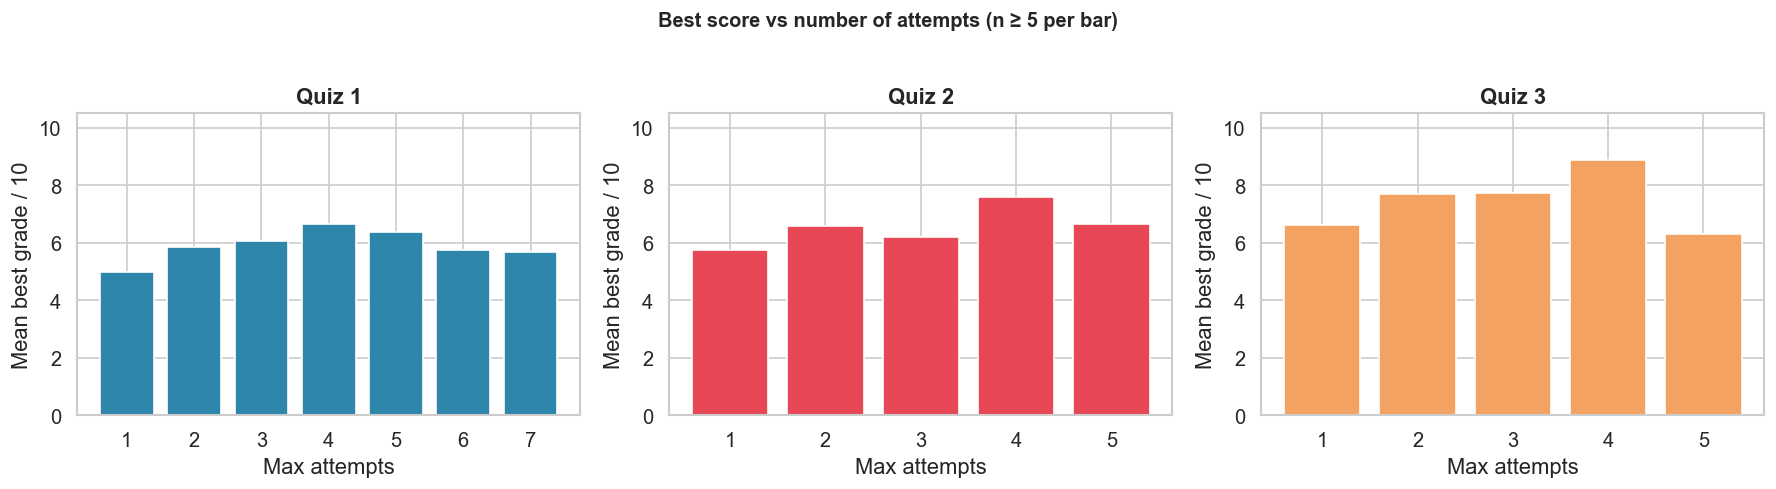

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, title), c in zip(axes, triplets(q1, q2, q3), COLORS):
    s = df.groupby("student_id").agg(best=("grade", "max"), n=("attempt_no", "max")).reset_index()
    agg = s.groupby("n")["best"].agg(["mean", "count"]).reset_index()
    agg = agg[agg["count"] >= 5]
    ax.bar(agg["n"].astype(int).astype(str), agg["mean"], color=c, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Max attempts")
    ax.set_ylabel("Mean best grade / 10")
    ax.set_ylim(0, 10.5)
plt.suptitle("Best score vs number of attempts (n ≥ 5 per bar)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / "eda_best_grade_by_max_attempts.png", bbox_inches="tight")
plt.show()


## Summary

Outputs under `outputs/eda/` mirror `python -m src eda` (see `src/eda.py` `run_all_eda_plots` and `write_manifest`).
